In [1]:
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os

import amigo


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/easy_binary/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "cal_vis.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M', 'F430M', 'F480M'])


In [3]:
ois = [
    amigo.vis_analysis.AmigoOIData(oi_data) for filt, oi_data in cal_vis_outputs.items()
]
oi = ois[-1]

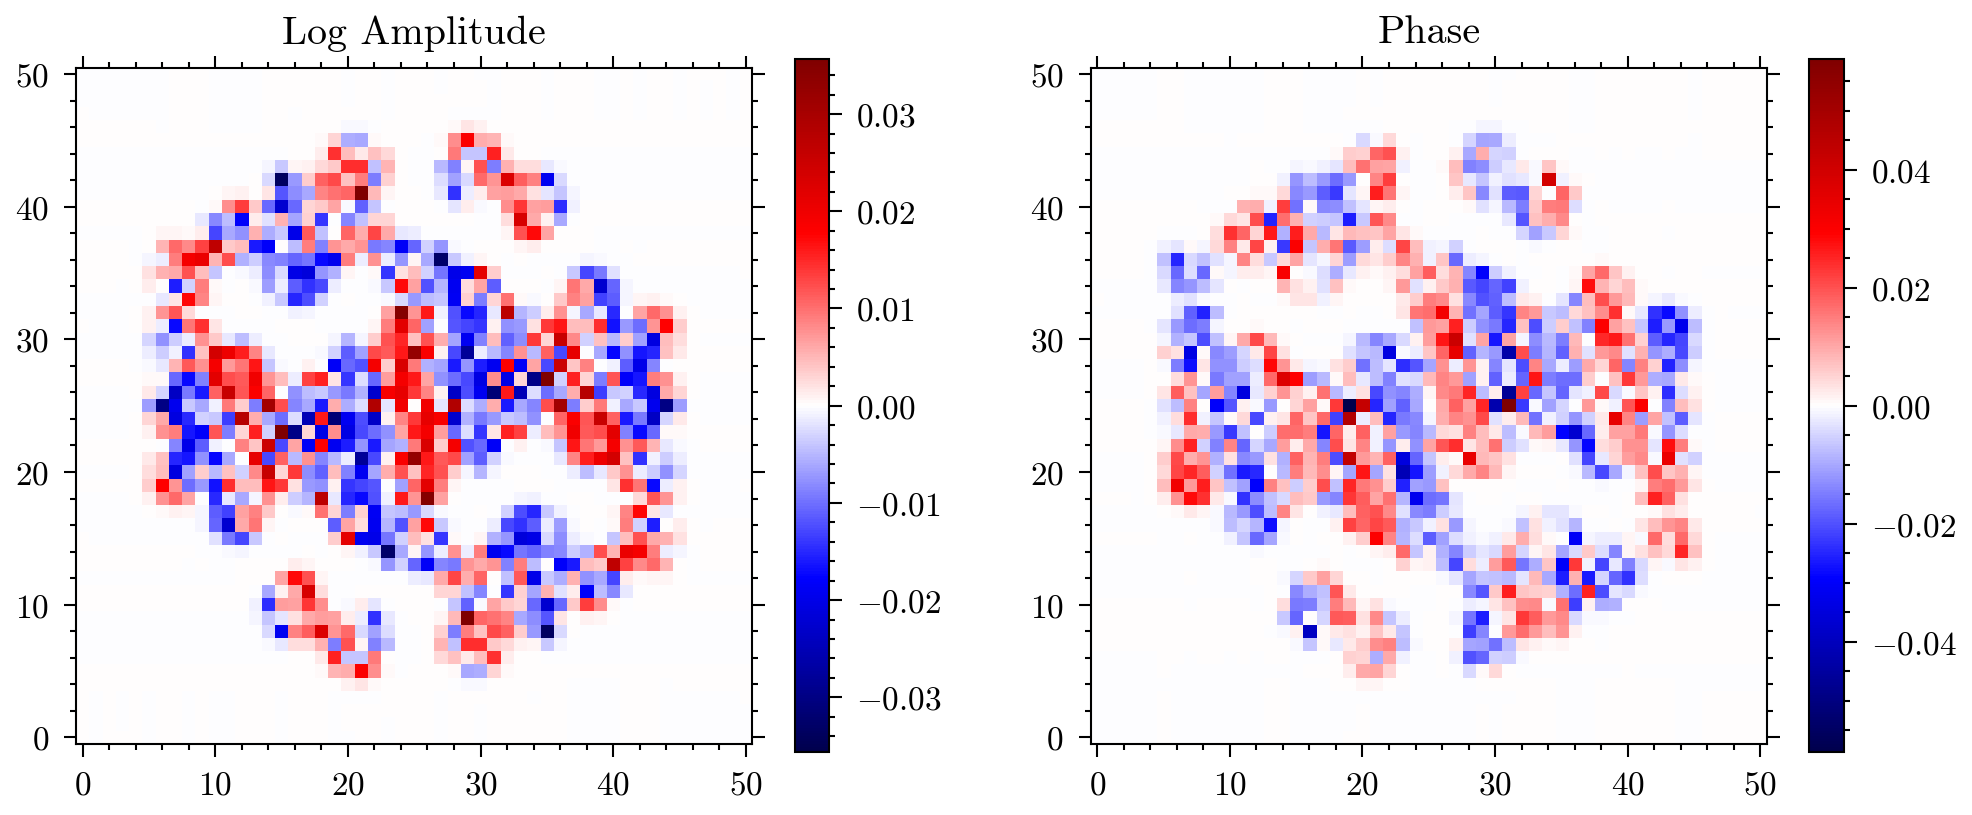

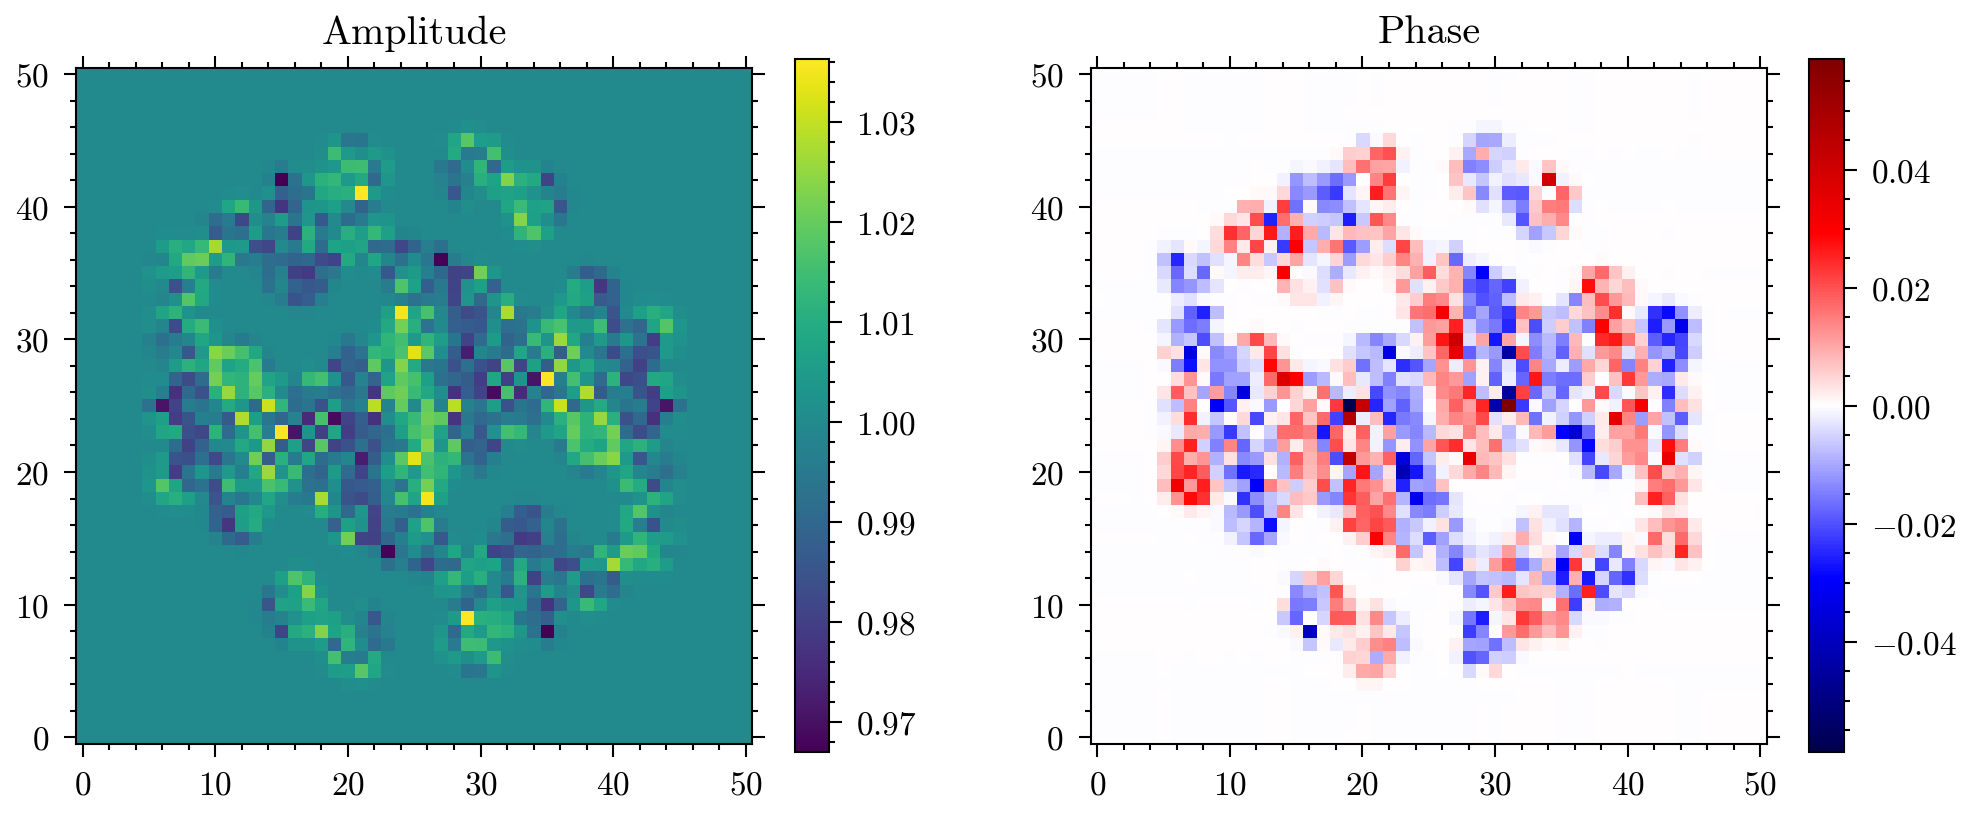

In [4]:
from amigo.vis_models import vis_to_im

# Get the discos
data, err = oi.flatten_data()
orig_log_amp, orig_phase = np.array_split(data, 2)

# Project to pixels
log_amp = np.dot(np.linalg.pinv(oi.vis_mat), orig_log_amp)
phase = np.dot(np.linalg.pinv(oi.phi_mat), orig_phase)

uv_npix = 51
log_amp, phase = vis_to_im(log_amp, phase, (uv_npix, uv_npix))

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Log Amplitude")
plt.imshow(log_amp, cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.subplot(122)
plt.title("Phase")
plt.imshow(phase, cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()


pix_cvis = np.exp(log_amp + 1j * phase)


plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Amplitude")
plt.imshow(np.abs(pix_cvis), cmap=viridis)
plt.colorbar()
plt.subplot(122)
plt.title("Phase")
plt.imshow(np.angle(pix_cvis), cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

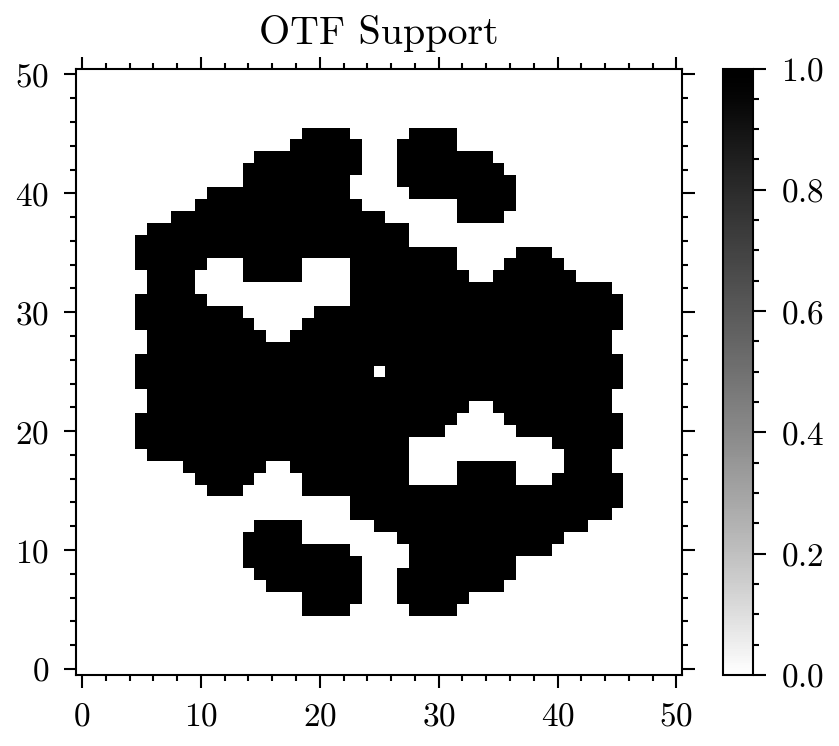

In [5]:
from jax import vmap

# Project to pixels
rand_vals = jr.normal(jr.key(0), (1000, *orig_log_amp.shape))
rand_amp = vmap(lambda x: np.dot(np.linalg.pinv(oi.vis_mat), x))(rand_vals)
rand_phase = vmap(lambda x: np.dot(np.linalg.pinv(oi.phi_mat), x))(rand_vals)
rand_amp, rand_phase = vmap(lambda a, p: vis_to_im(a, p, (51, 51)))(
    rand_amp, rand_phase
)

otf_support = rand_amp.var(0) > 0.01

# masking
masked_pix_cvis = np.where(otf_support, pix_cvis, 0 + 0j)

plt.imshow(otf_support, cmap="gray_ur", vmin=0, vmax=1)
plt.colorbar()
plt.title("OTF Support")
plt.show()

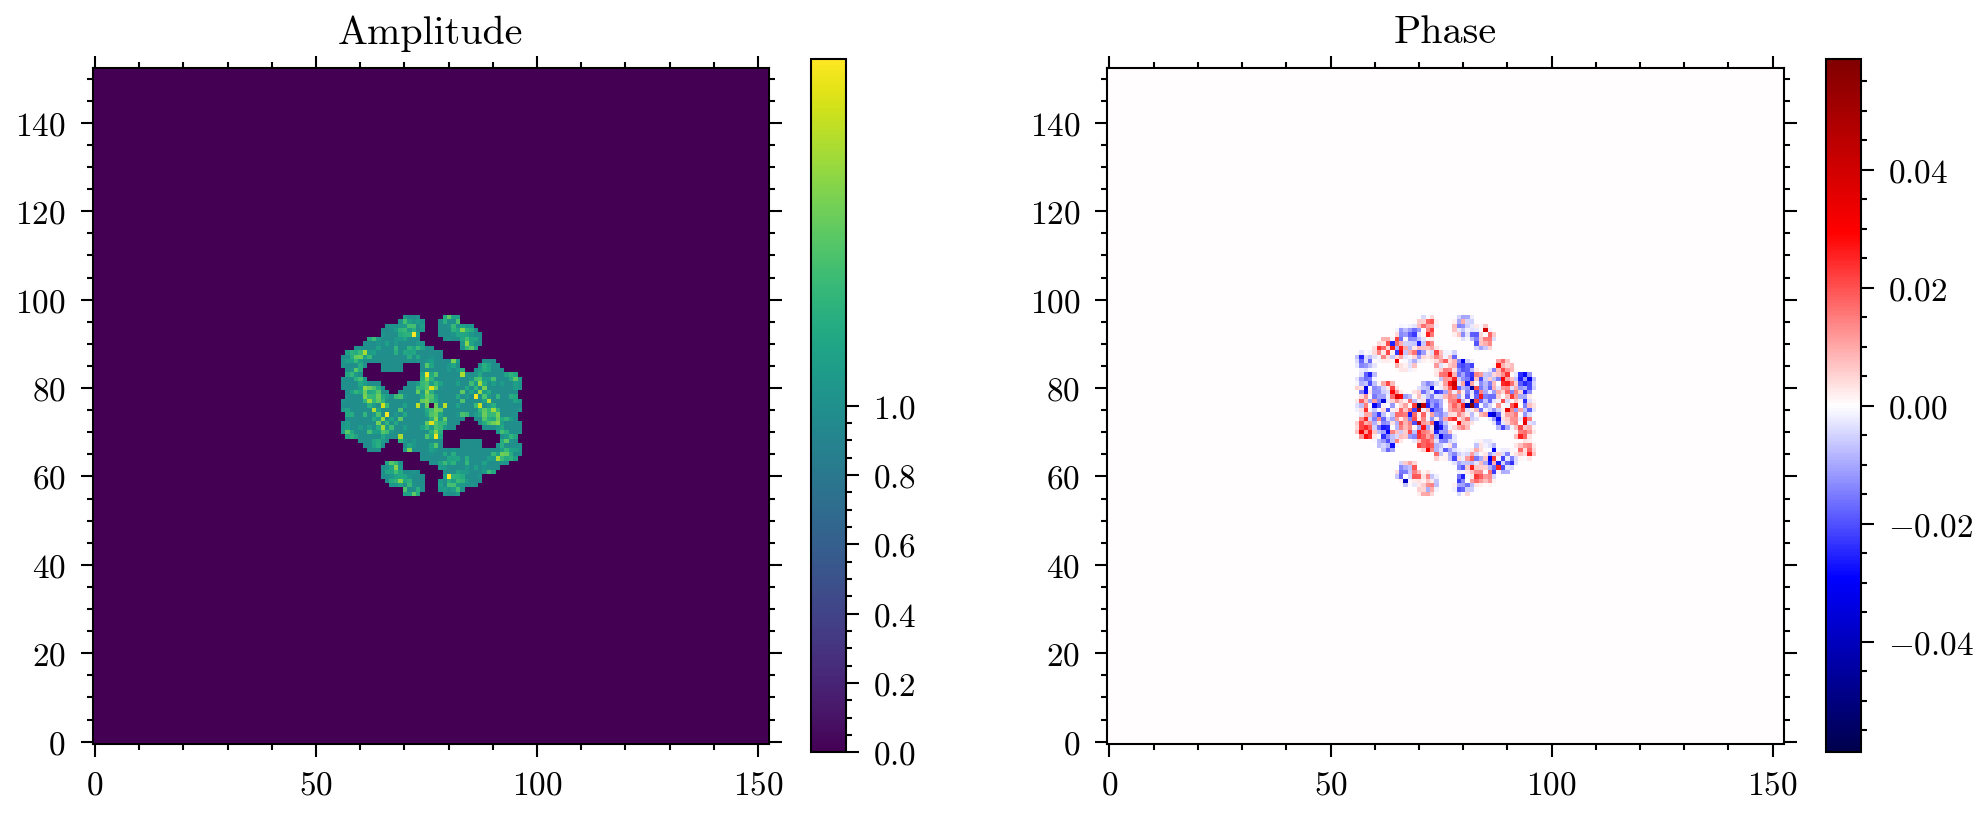

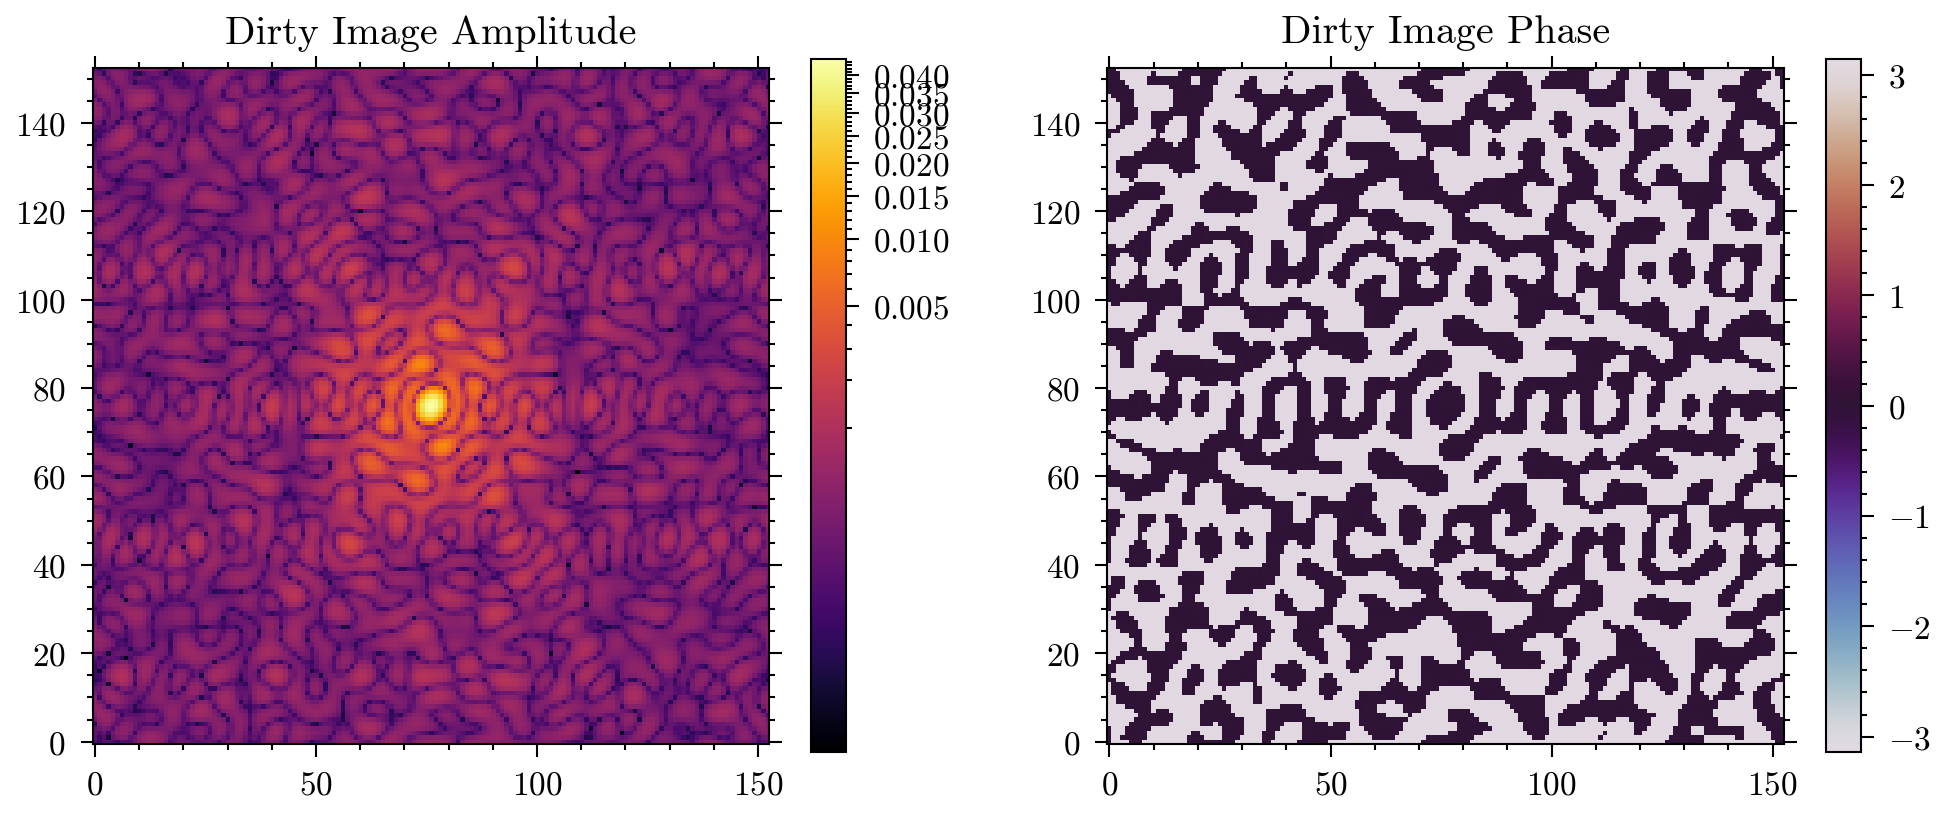

In [6]:
pad = 1

pix_cvis_pad = np.pad(
    masked_pix_cvis, uv_npix * pad, mode="constant", constant_values=0 + 0j
)

dirty_im = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(pix_cvis_pad)))


plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Amplitude")
plt.imshow(np.abs(pix_cvis_pad), cmap=viridis, norm=mpl.colors.TwoSlopeNorm(1.0))
plt.colorbar()
plt.subplot(122)
plt.title("Phase")
plt.imshow(np.angle(pix_cvis_pad), cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()


plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Dirty Image Amplitude")
plt.imshow(np.abs(dirty_im), cmap=inferno, norm=mpl.colors.PowerNorm(0.2))
plt.colorbar()
plt.subplot(122)
plt.title("Dirty Image Phase")
plt.imshow(np.angle(dirty_im), cmap="twilight", norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

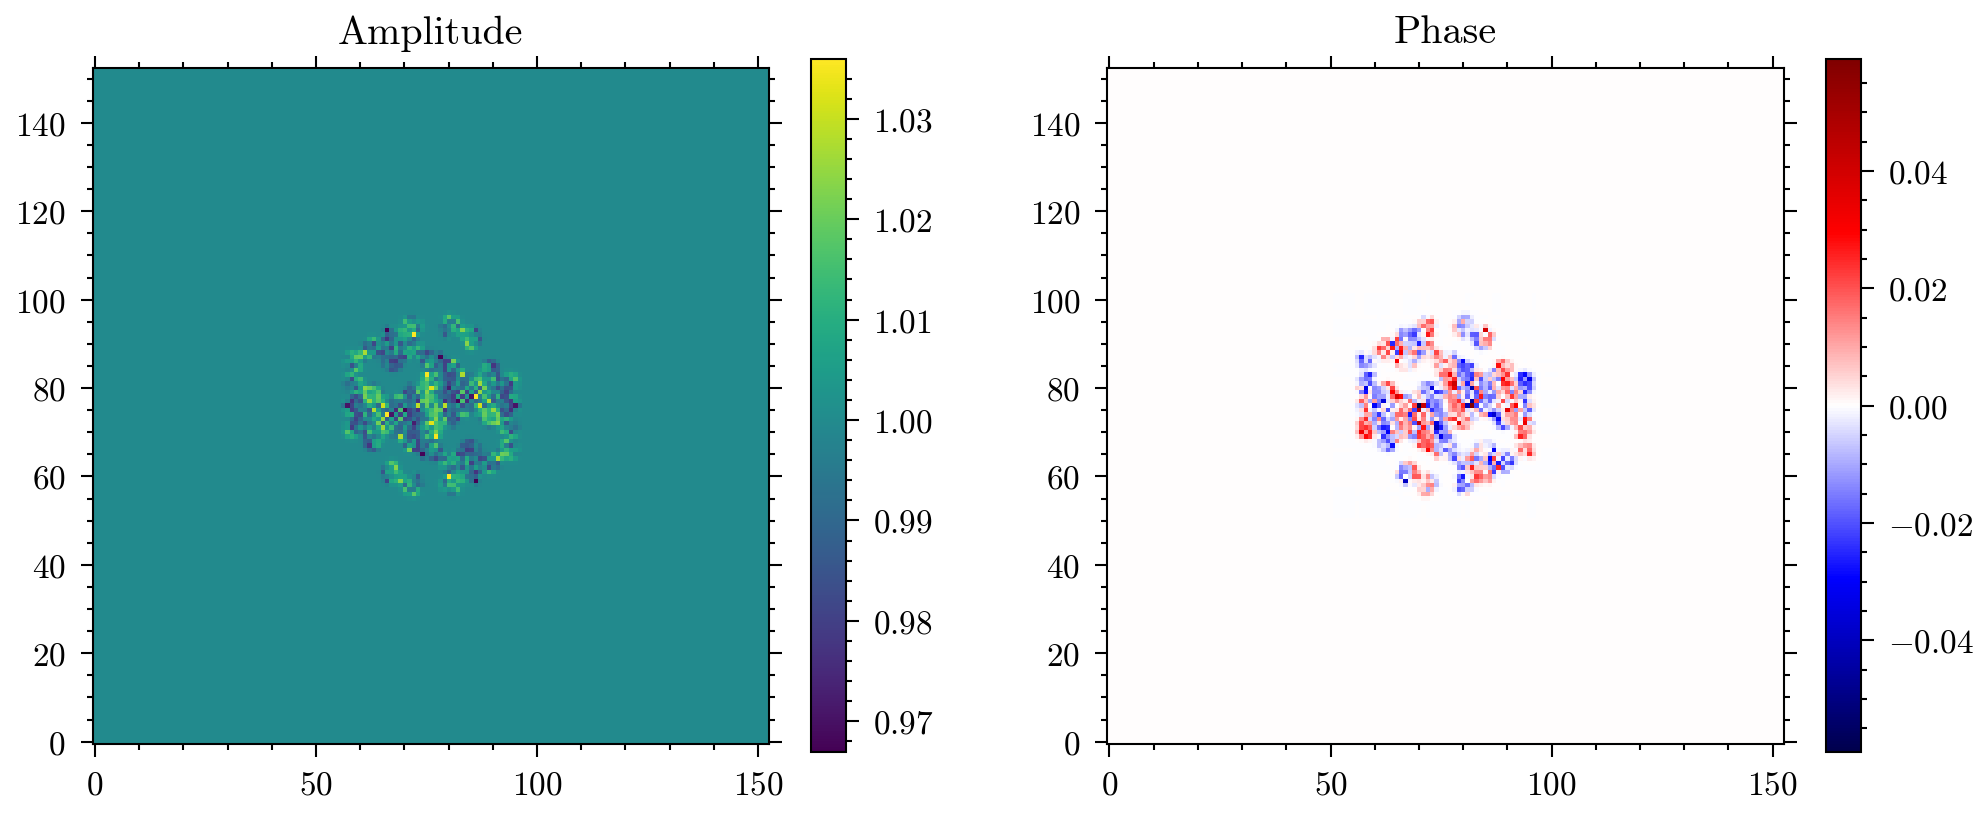

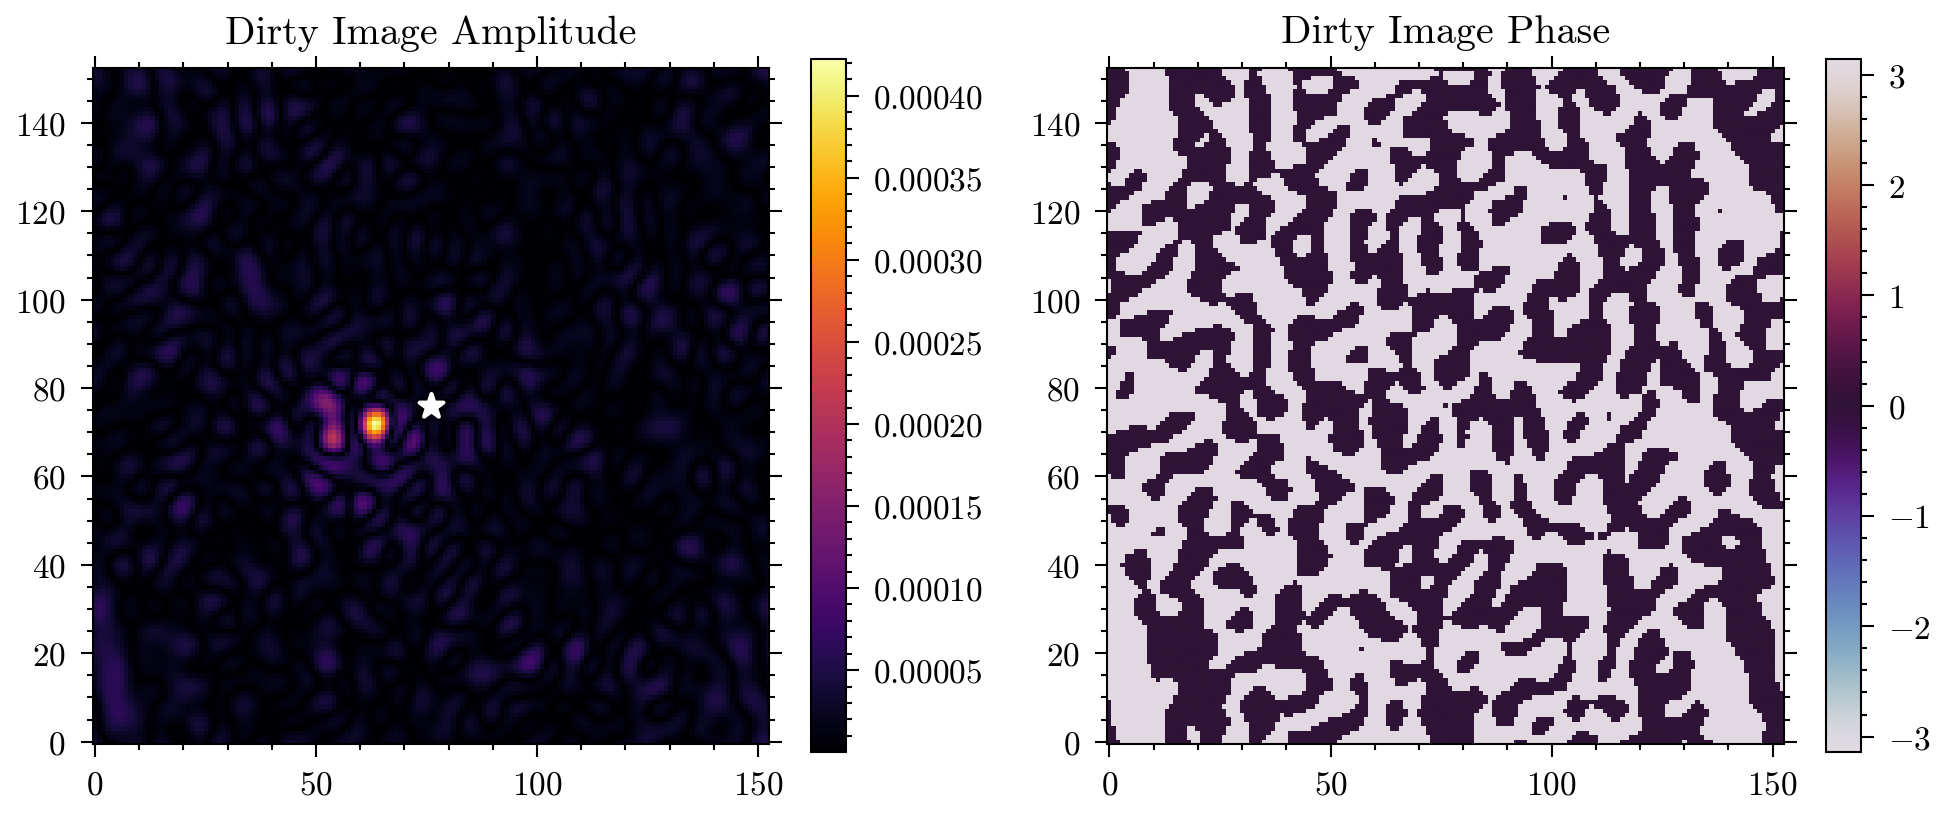

In [7]:
pad = 1
pix_cvis_pad = np.pad(pix_cvis, uv_npix * pad, mode="constant", constant_values=1 + 0j)

dirty_im = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(pix_cvis_pad)))


plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Amplitude")
plt.imshow(pix_cvis_pad.real, cmap=viridis)
plt.colorbar()
plt.subplot(122)
plt.title("Phase")
plt.imshow(pix_cvis_pad.imag, cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()


plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Dirty Image Amplitude")
plt.scatter(
    [dirty_im.shape[0] // 2], [dirty_im.shape[0] // 2], marker="*", color="white"
)
plt.imshow(
    np.abs(dirty_im).at[dirty_im.shape[0] // 2, dirty_im.shape[0] // 2].set(np.nan),
    cmap=inferno,
)
plt.colorbar()
plt.subplot(122)
plt.title("Dirty Image Phase")
plt.imshow(np.angle(dirty_im), cmap="twilight", norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

In [8]:
# Create a 2D Gaussian array with the same shape as log_amp
def gaussian_2d(shape, center=None, sigma=10, order=1):
    x = np.arange(shape[1])
    y = np.arange(shape[0])
    x, y = np.meshgrid(x, y)
    if center is None:
        center = (shape[1] // 2, shape[0] // 2)
    gauss = np.exp(-((x - center[0]) ** 2 + (y - center[1]) ** 2) / (2 * sigma**2))

    gauss = gauss**order
    return gauss / gauss.max()

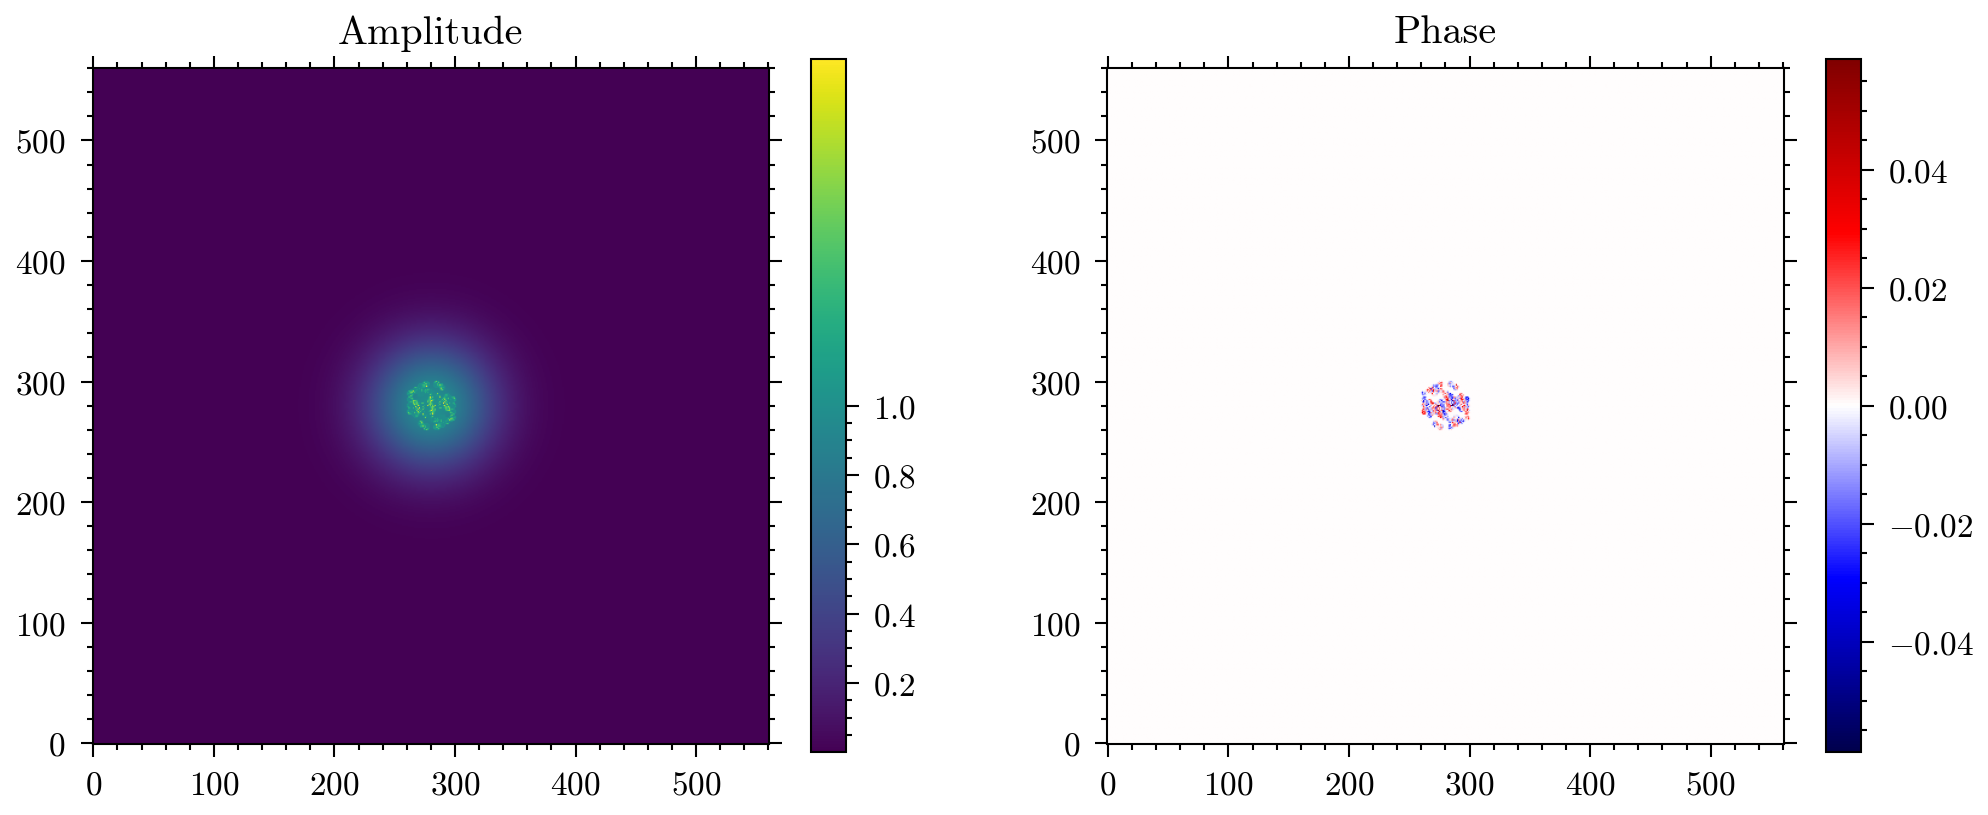

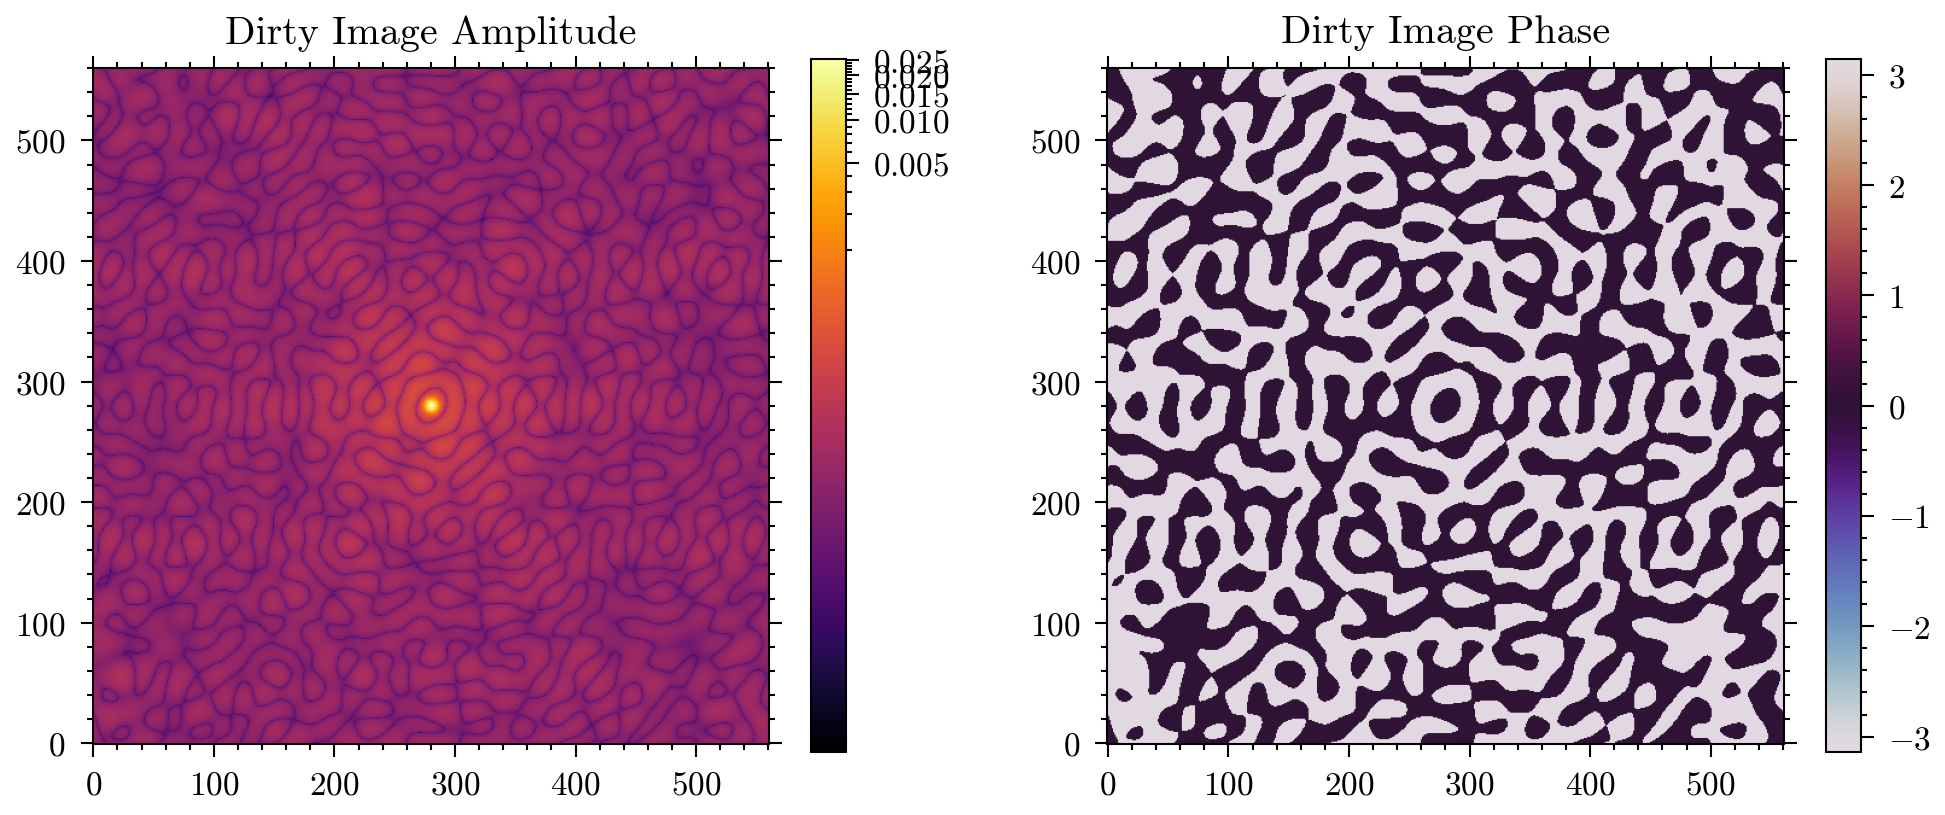

In [9]:
pad = 5
pix_cvis_pad = np.pad(pix_cvis, uv_npix * pad, mode="linear_ramp")
otf_support_pad = np.pad(otf_support, uv_npix * pad, mode="empty")
taper = gaussian_2d(pix_cvis_pad.shape, sigma=50, order=2)

taper_pix_cvis = np.where(otf_support_pad, pix_cvis_pad, taper + 0j)

dirty_im = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(taper_pix_cvis)))


plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Amplitude")
plt.imshow(np.abs(taper_pix_cvis), cmap=viridis, norm=mpl.colors.TwoSlopeNorm(1.0))
plt.colorbar()
plt.subplot(122)
plt.title("Phase")
plt.imshow(np.angle(taper_pix_cvis), cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()


plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Dirty Image Amplitude")
plt.imshow(
    np.abs(dirty_im),
    norm=mpl.colors.PowerNorm(0.1),
    cmap=inferno,
)
plt.colorbar()
plt.subplot(122)
plt.title("Dirty Image Phase")
plt.imshow(np.angle(dirty_im), cmap="twilight", norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

In [10]:
cvis1 = pix_cvis.flatten()[: oi.u.size]
cvis2 = pix_cvis.flatten()[oi.u.size + 1 :]
otf1 = otf_support.flatten()[: oi.u.size]
otf2 = otf_support.flatten()[oi.u.size + 1 :]
us_in1 = oi.u[otf1]
us_in2 = -oi.u[::-1][otf2]
vs_in1 = oi.v[otf1]
vs_in2 = -oi.v[::-1][otf2]
cvis_in1 = cvis1[otf1]
cvis_in2 = cvis2[otf2]

print(pix_cvis.shape)
print(oi.u.shape, oi.v.shape)
print(cvis1.shape, cvis2.shape)
print(otf1.shape, otf2.shape)
print(us_in1.shape, us_in2.shape)
print(vs_in1.shape, vs_in2.shape)
print(cvis_in1.shape, cvis_in2.shape)

(51, 51)
(1300,) (1300,)
(1300,) (1300,)
(1300,) (1300,)
(526,) (526,)
(526,) (526,)
(526,) (526,)


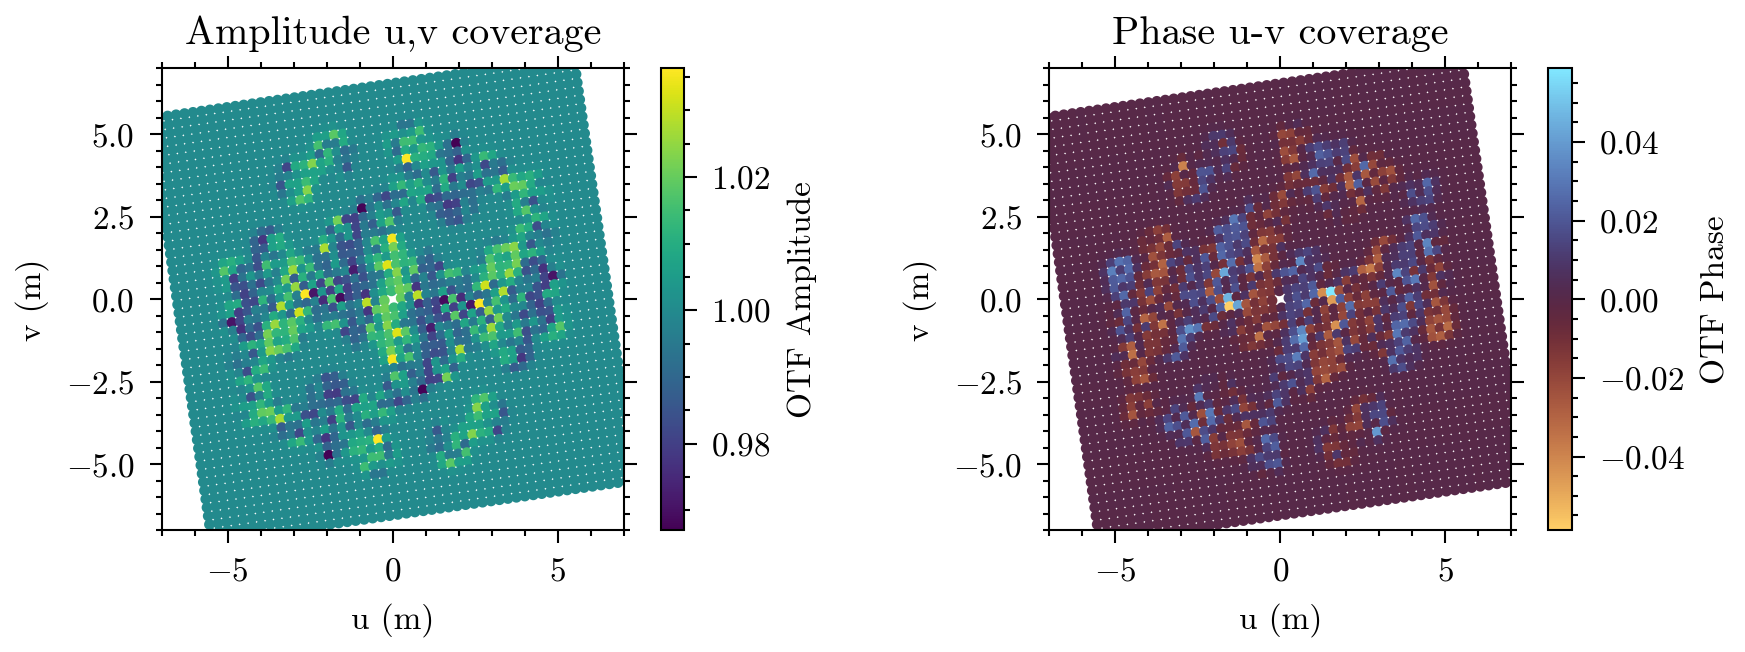

In [11]:
plt.figure(figsize=(7, 2))
plt.subplot(121)
plt.scatter(oi.u, oi.v, marker="o", s=2.5, c=np.abs(cvis1), cmap="viridis")
plt.scatter(
    -oi.u[::-1], -oi.v[::-1], marker="o", s=2.5, c=np.abs(cvis2), cmap="viridis"
)
plt.axis("square")
plt.xlabel("u (m)")
plt.ylabel("v (m)")
plt.title("Amplitude u,v coverage")
plt.colorbar(label="OTF Amplitude")
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.subplot(122)
plt.scatter(
    oi.u,
    oi.v,
    marker="o",
    s=2.5,
    c=np.angle(cvis1),
    cmap="managua",
    norm=mpl.colors.CenteredNorm(),
)
plt.scatter(
    -oi.u[::-1],
    -oi.v[::-1],
    marker="o",
    s=2.5,
    c=np.angle(cvis2),
    cmap="managua",
    norm=mpl.colors.CenteredNorm(),
)
plt.axis("square")
plt.xlabel("u (m)")
plt.ylabel("v (m)")
plt.title("Phase u-v coverage")
plt.colorbar(label="OTF Phase")
plt.xlim(-7, 7)
plt.ylim(-7, 7)

plt.show()

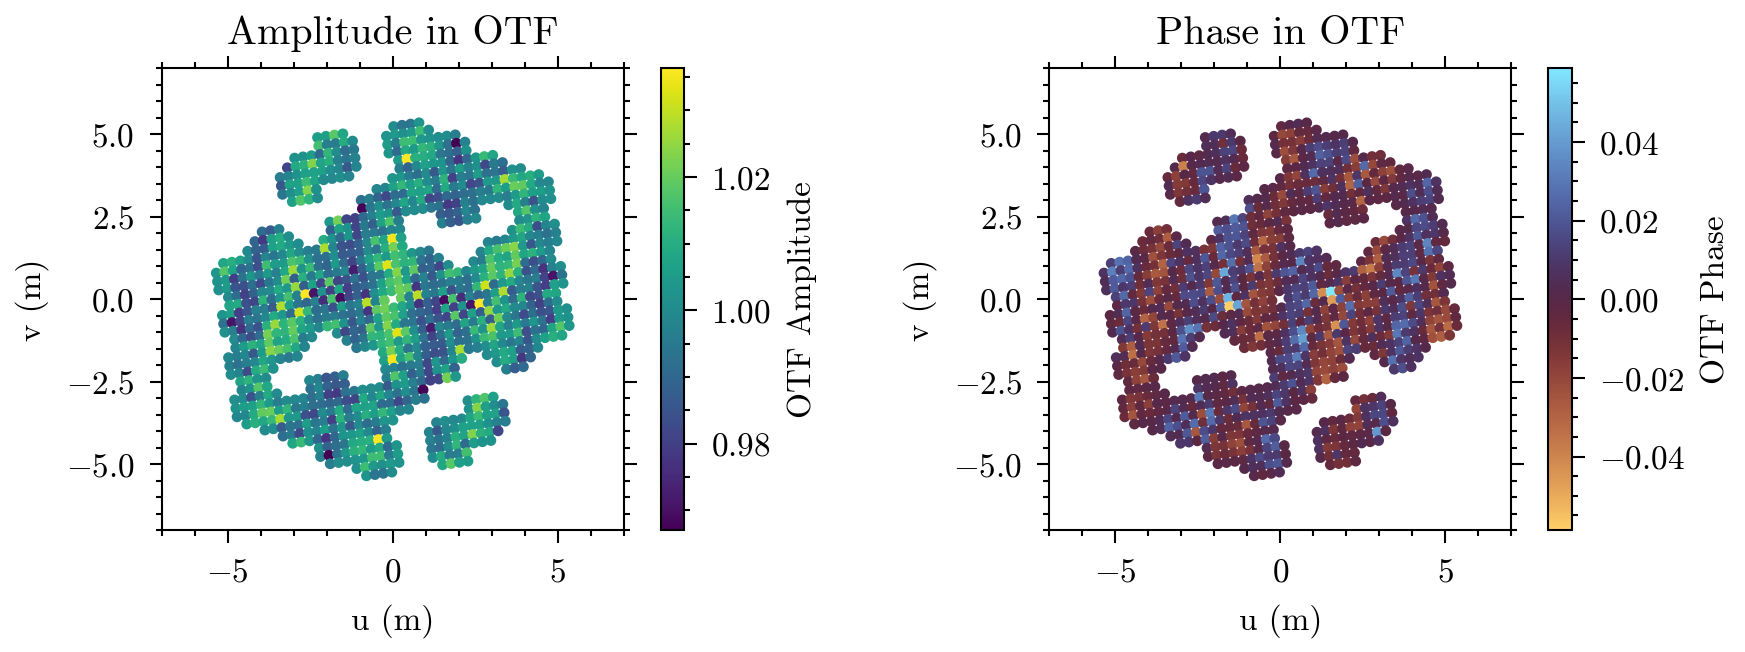

In [12]:
plt.figure(figsize=(7, 2))
plt.subplot(121)
plt.scatter(us_in1, vs_in1, marker="o", s=2.5, c=np.abs(cvis_in1), cmap="viridis")
plt.scatter(us_in2, vs_in2, marker="o", s=2.5, c=np.abs(cvis_in2), cmap="viridis")
plt.axis("square")
plt.xlabel("u (m)")
plt.ylabel("v (m)")
plt.title("Amplitude in OTF")
plt.colorbar(label="OTF Amplitude")
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.subplot(122)
plt.scatter(
    us_in1,
    vs_in1,
    marker="o",
    s=2.5,
    c=np.angle(cvis_in1),
    cmap="managua",
    norm=mpl.colors.CenteredNorm(),
)
plt.scatter(
    us_in2,
    vs_in2,
    marker="o",
    s=2.5,
    c=np.angle(cvis_in2),
    cmap="managua",
    norm=mpl.colors.CenteredNorm(),
)
plt.axis("square")
plt.xlabel("u (m)")
plt.ylabel("v (m)")
plt.title("Phase in OTF")
plt.colorbar(label="OTF Phase")
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.show()

In [13]:
from jax_finufft import nufft1

uv_coords = np.vstack([us_in1, vs_in1])
uv_coords /= 3
print(uv_coords.shape)

vis = cvis_in1
print(vis.shape)

im_npix = 100

dirty_image = nufft1((im_npix, im_npix), vis, *uv_coords)

(2, 526)
(526,)


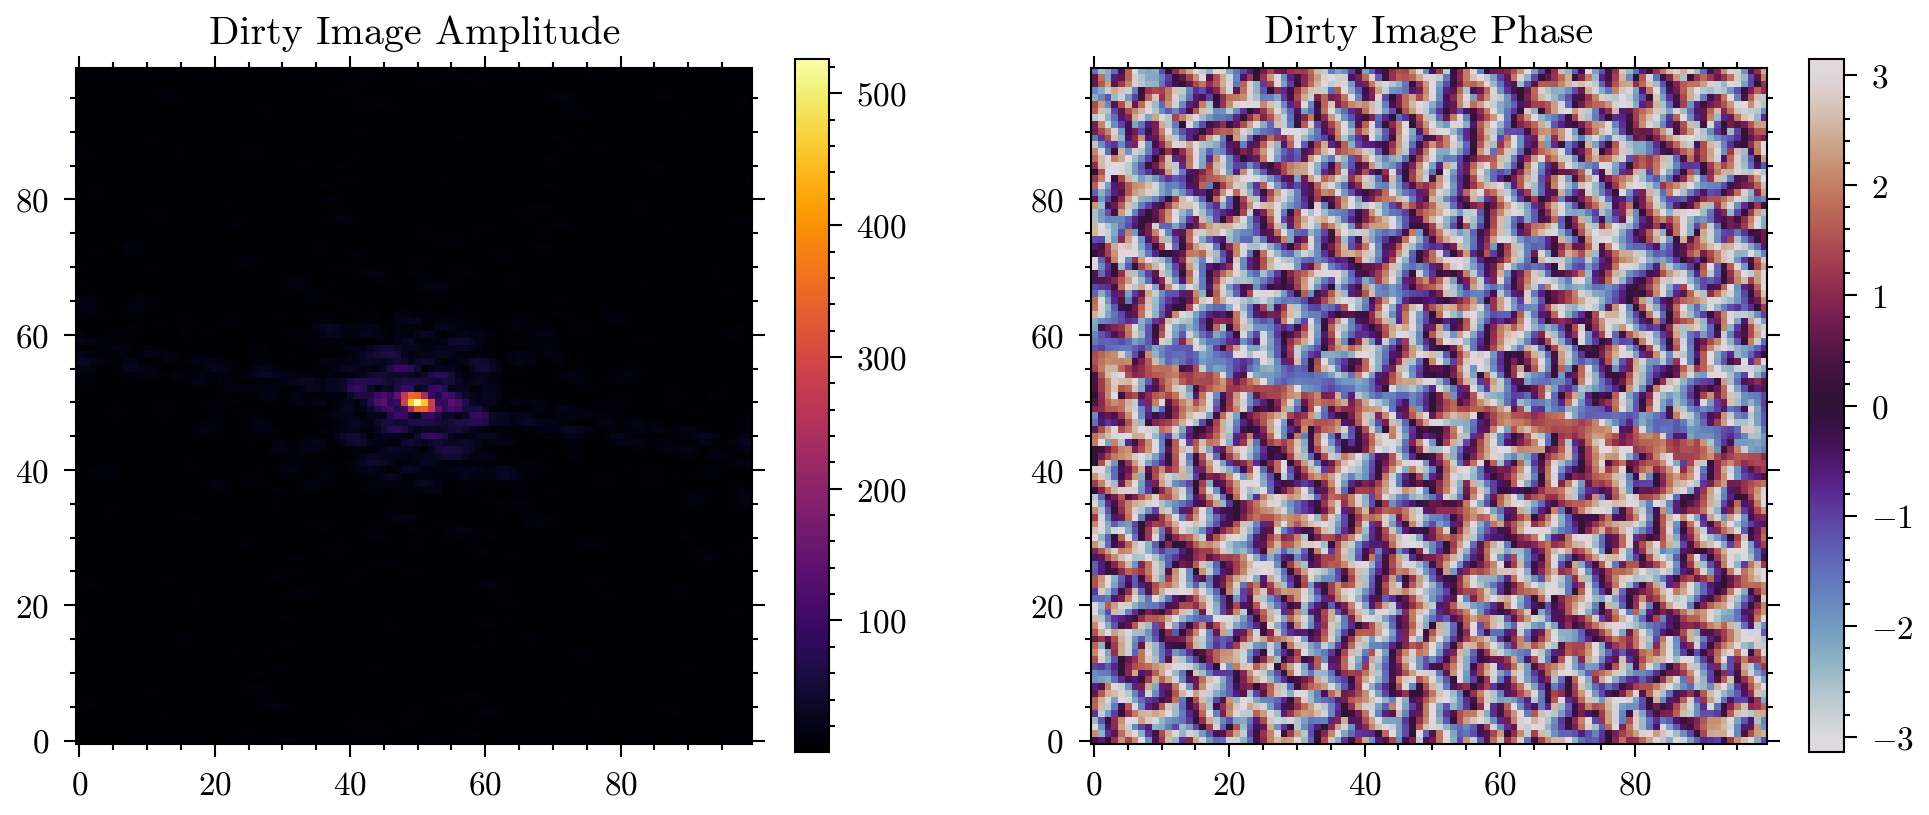

In [14]:
plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Dirty Image Amplitude")
plt.imshow(np.abs(dirty_image), cmap=inferno)
plt.colorbar()
plt.subplot(122)
plt.title("Dirty Image Phase")
plt.imshow(np.angle(dirty_image), cmap="twilight", norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

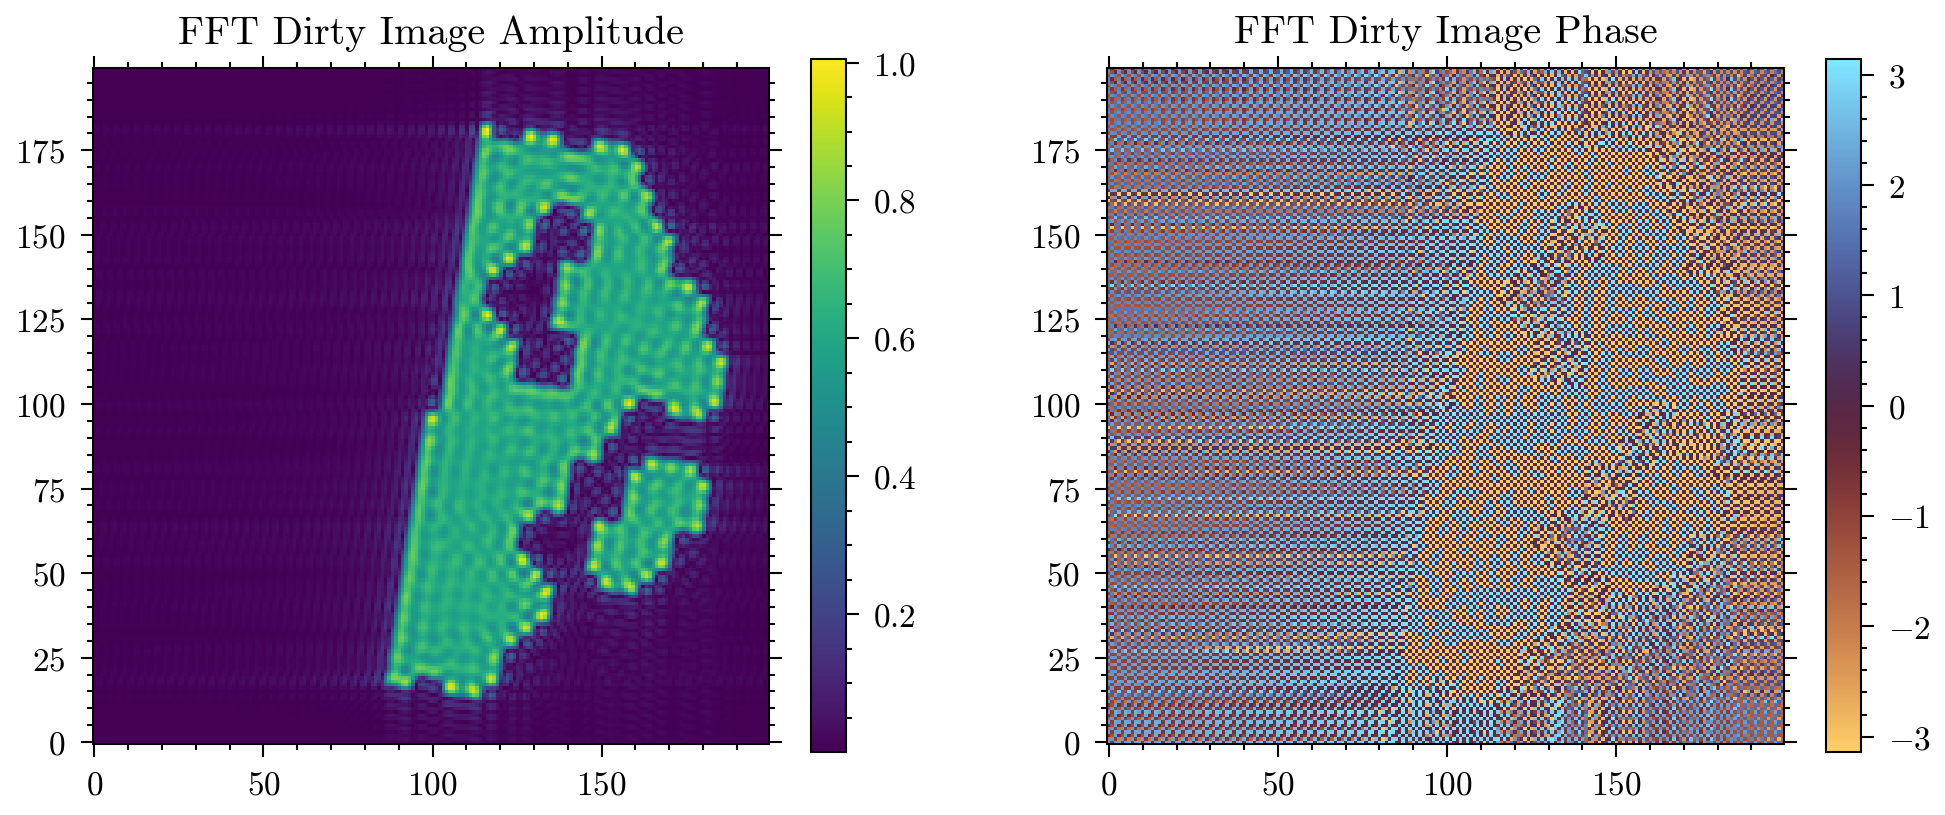

In [15]:
fft_dirty_image = np.fft.fftshift(np.fft.fft2(np.pad(dirty_image.copy(), 100)))
c = fft_dirty_image.shape[0] // 2
fft_dirty_image = fft_dirty_image[c - 100 : c + 100, c - 100 : c + 100]

fft_dirty_image /= fft_dirty_image.max()

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("FFT Dirty Image Amplitude")
plt.imshow(np.abs(fft_dirty_image), cmap=viridis)
plt.colorbar()
plt.subplot(122)
plt.title("FFT Dirty Image Phase")
plt.imshow(np.angle(fft_dirty_image), cmap="managua", norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

In [16]:
from jax_finufft import nufft1

uv_coords = np.vstack([us_in1, vs_in1])
uv_coords = oi.wavel / uv_coords
print(uv_coords.shape)

vis = cvis_in1
print(vis.shape)

im_npix = 4000

dirty_image = nufft1((im_npix, im_npix), vis, *uv_coords)

(2, 526)
(526,)


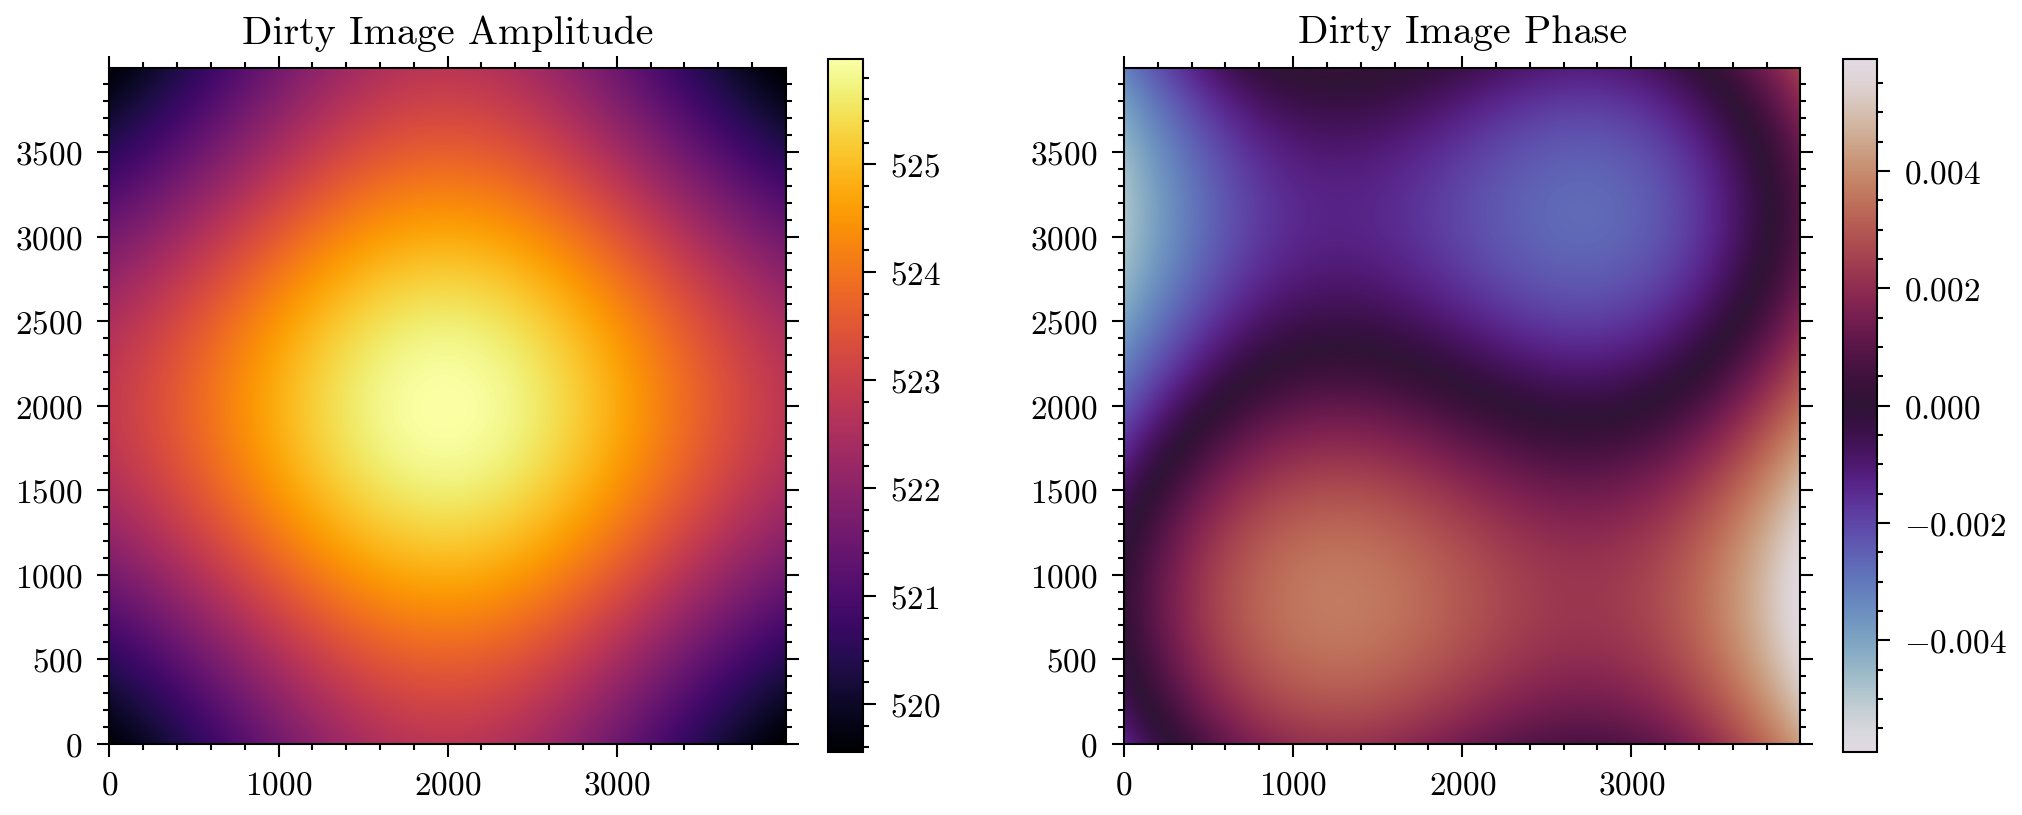

In [17]:
plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Dirty Image Amplitude")
plt.imshow(np.abs(dirty_image), cmap=inferno)
plt.colorbar()
plt.subplot(122)
plt.title("Dirty Image Phase")
plt.imshow(np.angle(dirty_image), cmap="twilight", norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

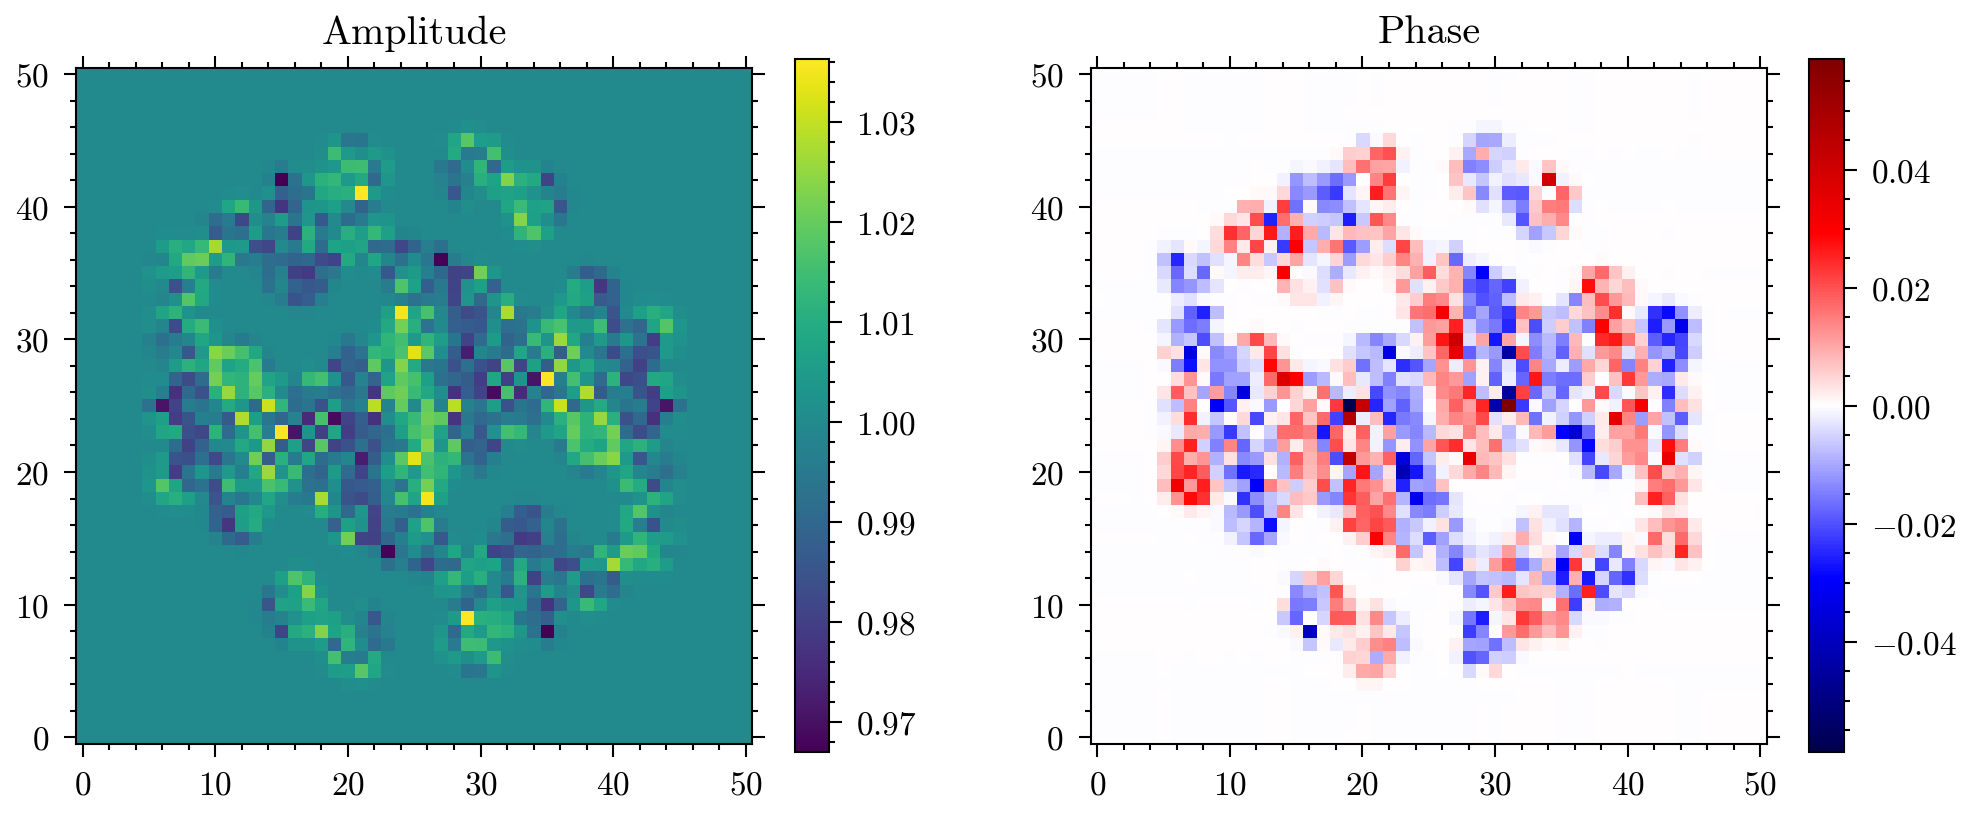

In [18]:
from amigo.vis_models import vis_to_im

# Get the discos
data, err = oi.flatten_data()
orig_log_amp, orig_phase = np.array_split(data, 2)

# Project to pixels
log_amp = np.dot(np.linalg.pinv(oi.vis_mat), orig_log_amp)
phase = np.dot(np.linalg.pinv(oi.phi_mat), orig_phase)

uv_npix = 51
log_amp, phase = vis_to_im(log_amp, phase, (uv_npix, uv_npix))

pix_cvis = np.exp(log_amp + 1j * phase)

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Amplitude")
plt.imshow(np.abs(pix_cvis), cmap=viridis)
plt.colorbar()
plt.subplot(122)
plt.title("Phase")
plt.imshow(np.angle(pix_cvis), cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

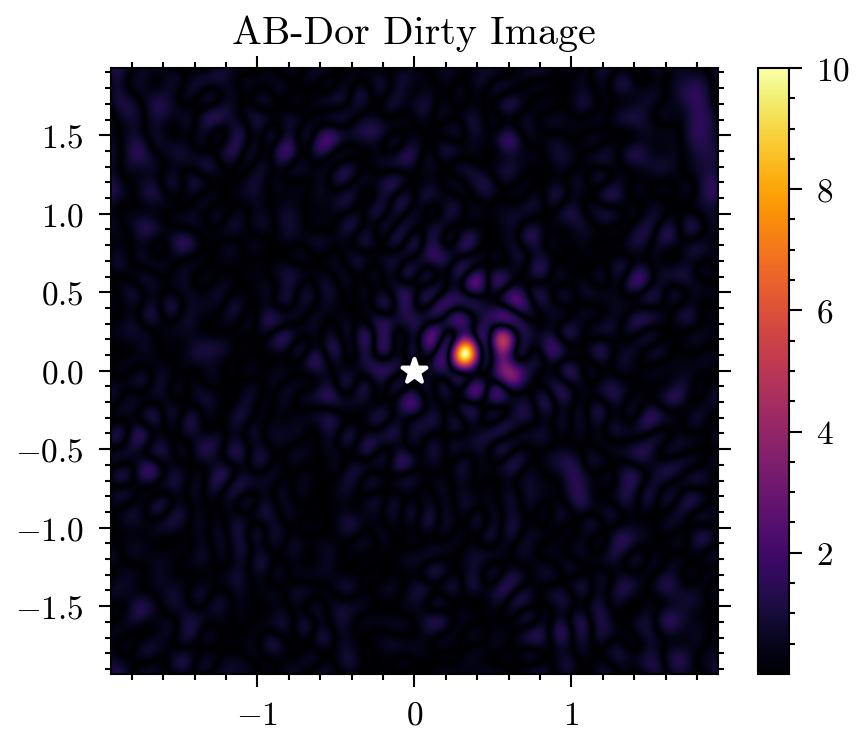

In [19]:
from dLux import utils as dlu

ifft = lambda x: np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(x)))

pad = 10
pad_pix_cvis = np.pad(pix_cvis, uv_npix * pad, mode="constant", constant_values=1 + 0j)

# have to make it an even number of pixels
pad_pix_cvis = np.pad(
    pad_pix_cvis, ((0, 1), (0, 1)), mode="constant", constant_values=1 + 0j
)

dirty_im = ifft(pad_pix_cvis)
# dirty_im = np.abs(dirty_im)

c = dirty_im.shape[0] // 2
plot_dirty_im = np.abs(dirty_im).at[c, c].set(np.nan)

# Coordinates
uv_pscale = np.diff(oi.u).mean()
im_npix = dirty_im.shape[0]
im_pscale = dlu.rad2arcsec(1 / (im_npix * (oi.u[1] - oi.u[0]) / oi.wavel))

extent = im_pscale * im_npix / 2
extent = (-extent, extent, -extent, extent)

plt.scatter(0, 0, marker="*", color="white")
plt.imshow(plot_dirty_im, cmap=inferno, extent=extent)
plt.colorbar()
plt.title("AB-Dor Dirty Image")
plt.show()

True


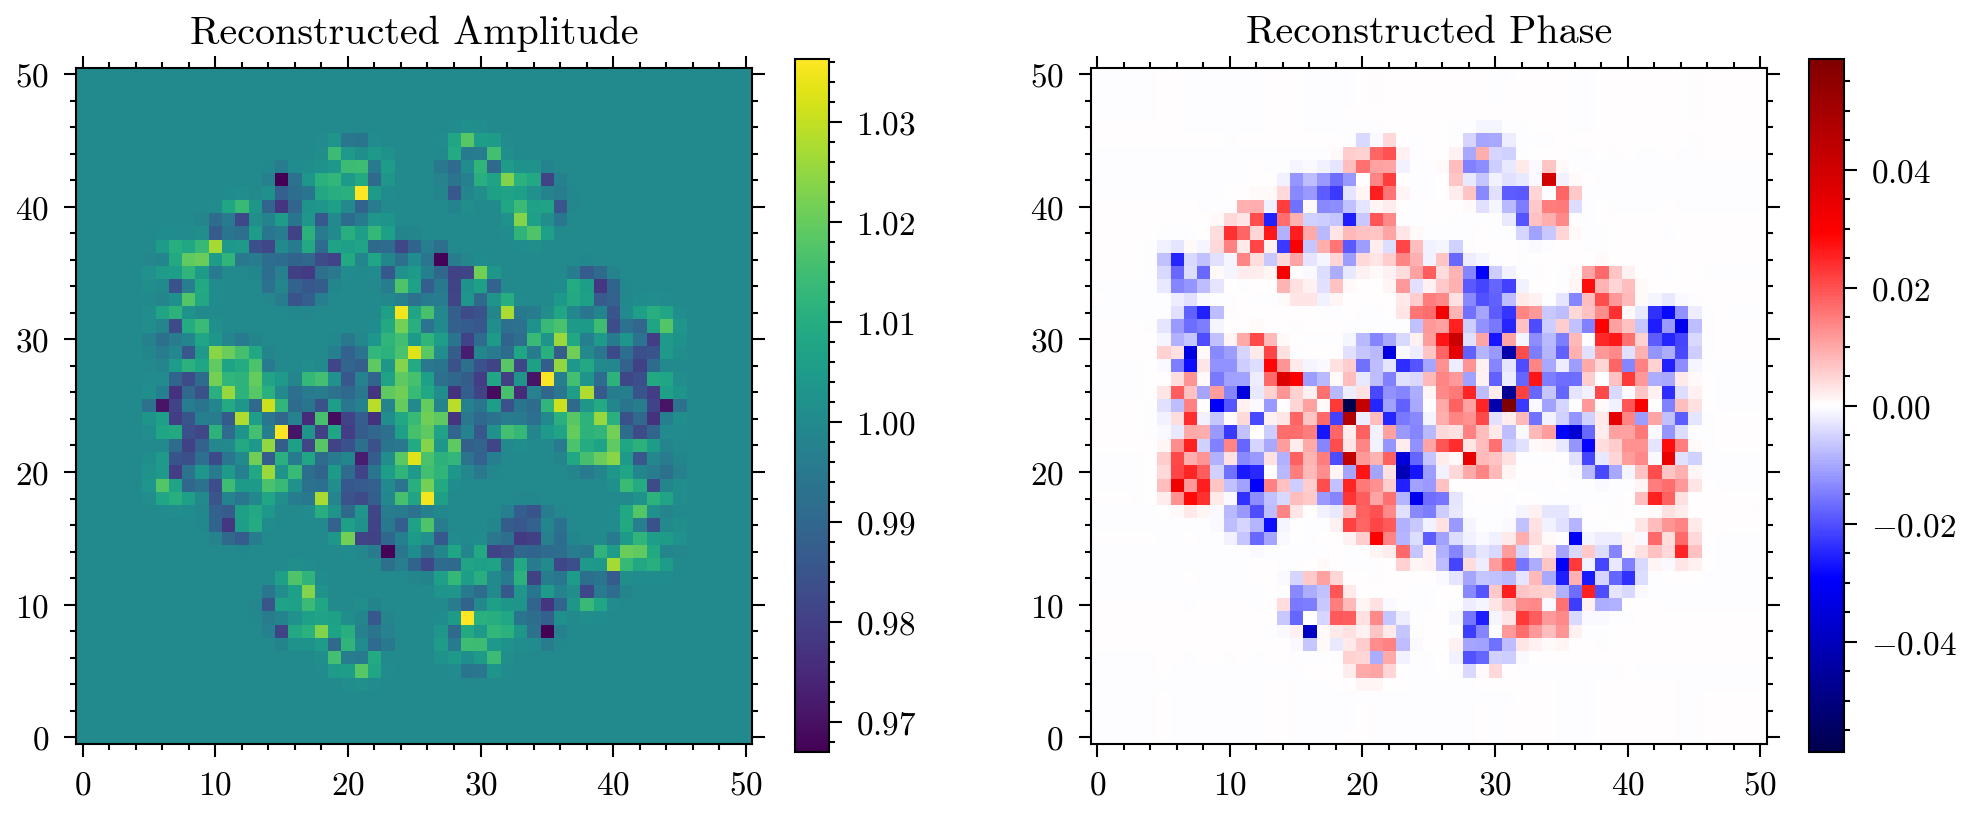

In [ ]:
fft = lambda x: np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(x)))

uv = fft(dirty_im)
uv = uv[:-1, :-1]  # remove the padding
p = 51 * pad
uv = uv[p:-p, p:-p]  # remove the padding
print(np.allclose(uv, pix_cvis))

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Reconstructed Amplitude")
plt.imshow(np.abs(uv), cmap=viridis)
plt.colorbar()
plt.subplot(122)
plt.title("Reconstructed Phase")
plt.imshow(np.angle(uv), cmap="seismic", norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

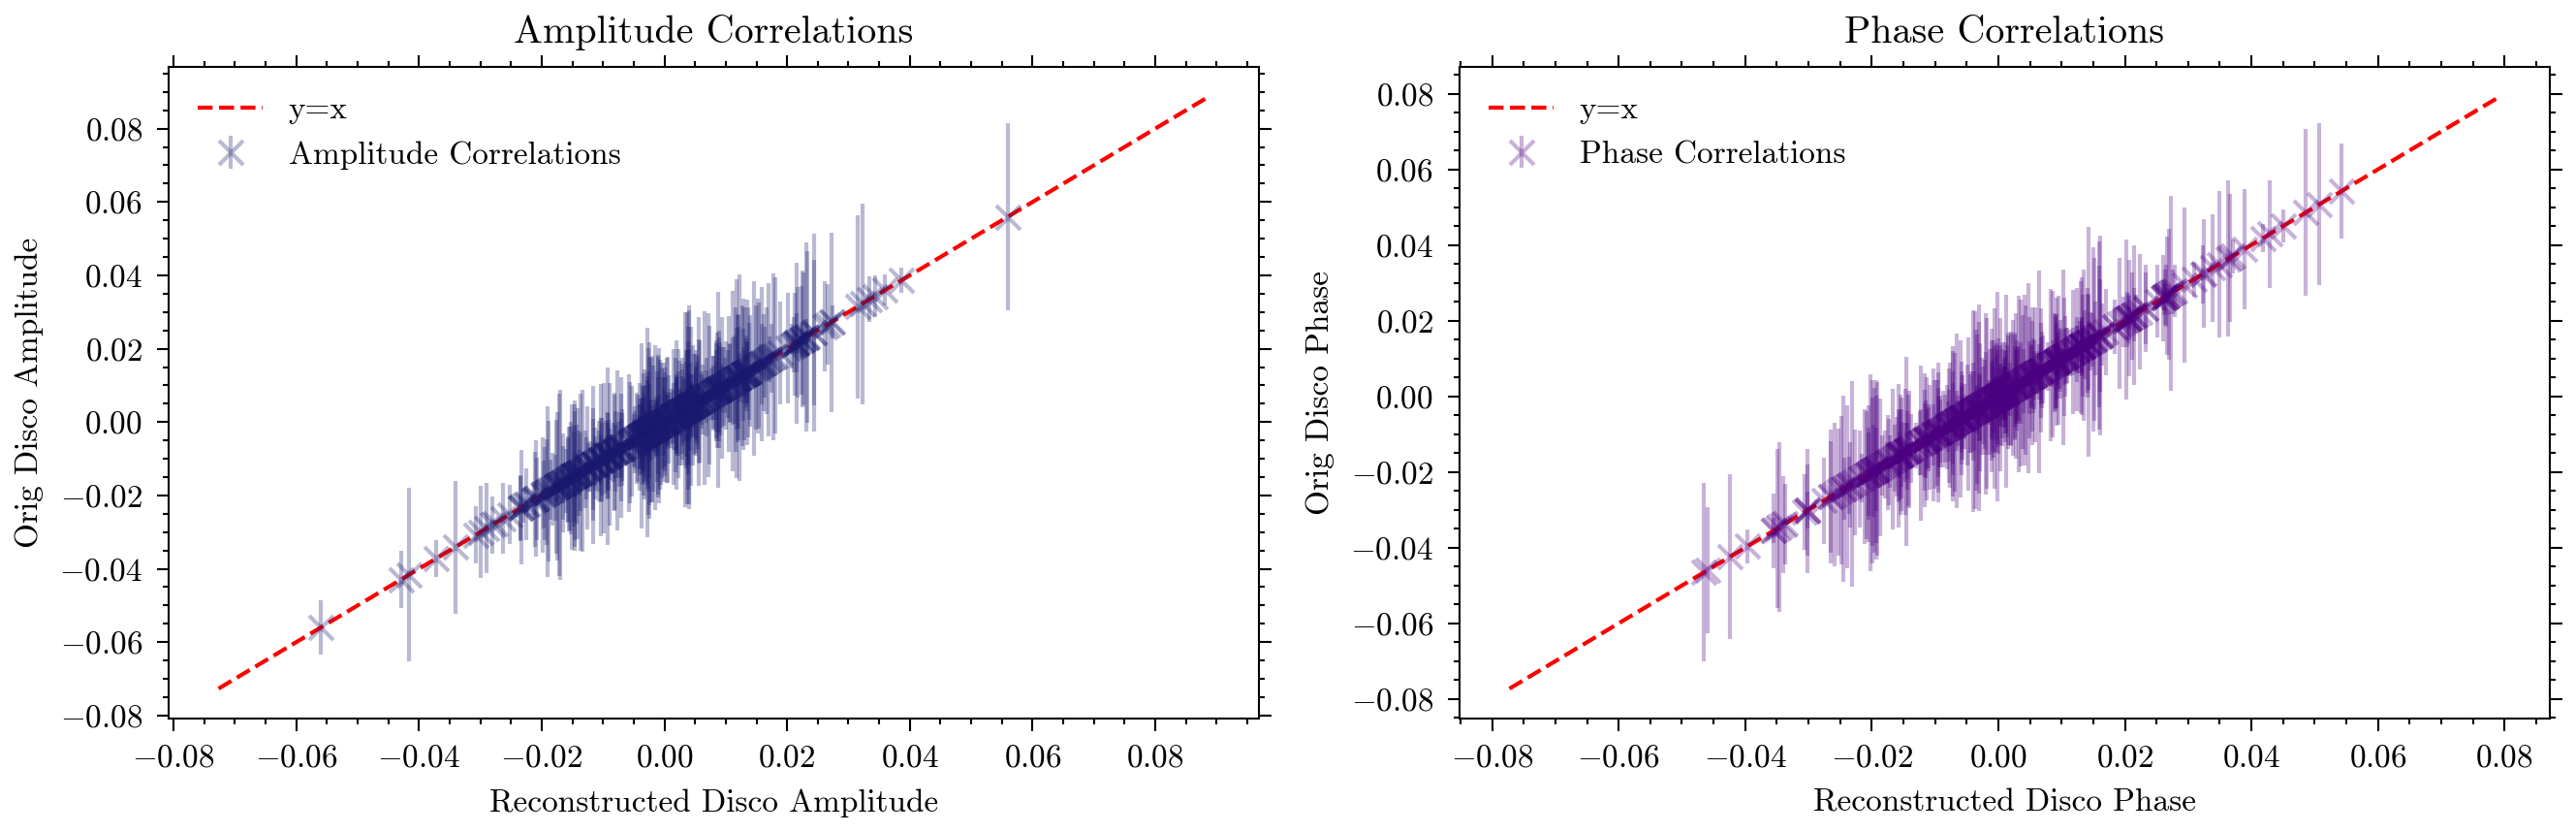

In [ ]:
cvis = uv.flatten()[: oi.u.size]
disco_amp, disco_phi = np.split(oi.flatten_model(cvis), 2)


fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

ax[0].errorbar(
    disco_amp,
    oi.vis,
    yerr=oi.d_vis,
    label="Amplitude Correlations",
    fmt="x",
    alpha=0.3,
    color="midnightblue",
)
x_min, x_max = ax[0].get_xlim()
y_min, y_max = ax[0].get_ylim()
min_val = min(x_min, y_min)
max_val = max(x_max, y_max)
ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
ax[0].set_title("Amplitude Correlations")
ax[0].set_xlabel("Reconstructed Disco Amplitude")
ax[0].set_ylabel("Orig Disco Amplitude")
ax[0].legend()

ax[1].errorbar(
    disco_phi,
    oi.phi,
    yerr=oi.d_phi,
    label="Phase Correlations",
    fmt="x",
    alpha=0.3,
    color="indigo",
)
x_min, x_max = ax[1].get_xlim()
y_min, y_max = ax[1].get_ylim()
min_val = min(x_min, y_min)
max_val = max(x_max, y_max)
ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
ax[1].set_title("Phase Correlations")
ax[1].set_xlabel("Reconstructed Disco Phase")
ax[1].set_ylabel("Orig Disco Phase")
ax[1].legend()

plt.tight_layout()
plt.show()